In [2]:
import pickle
import pandas as pd

with open("../data/processed/backtest_results.pkl", "rb") as f:
    results = pickle.load(f)

test = pd.read_pickle("../data/processed/test_data.pkl")
print("loaded!")

loaded!


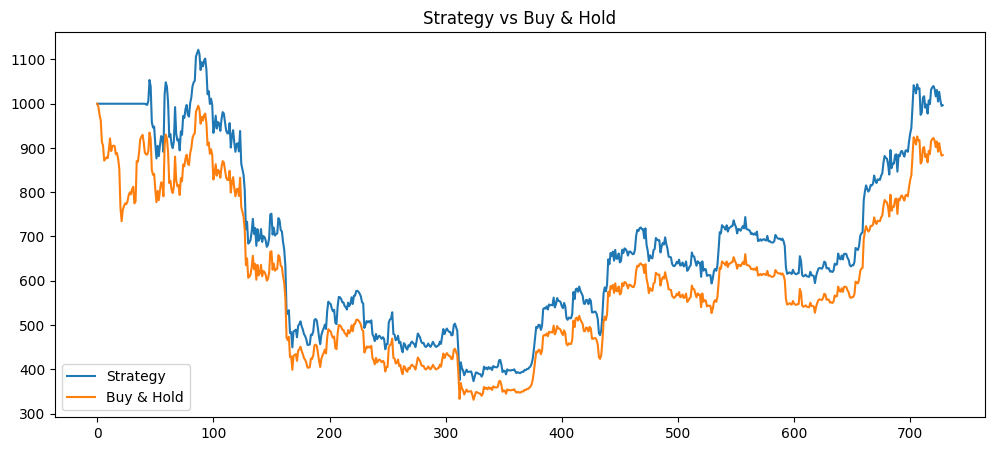

In [3]:
import matplotlib.pyplot as plt

prices = results['prices']
signals = results['signals']

# calculate strategy portfolio over time
portfolio = []
cash, btc = 1000, 0
fee = 0.0015

for i in range(len(signals)):
    price = prices[i]
    signal = signals[i]
    if signal == 1 and cash > 0:
        btc = (cash / price) * (1 - fee)
        cash = 0
    elif signal == -1 and btc > 0:
        cash = (btc * price) * (1 - fee)
        btc = 0
    portfolio.append(cash + btc * price)

buy_hold = [1000 * (p / prices[0]) for p in prices]

plt.figure(figsize=(12, 5))
plt.plot(portfolio, label='Strategy')
plt.plot(buy_hold, label='Buy & Hold')
plt.title('Strategy vs Buy & Hold')
plt.legend()
plt.show()

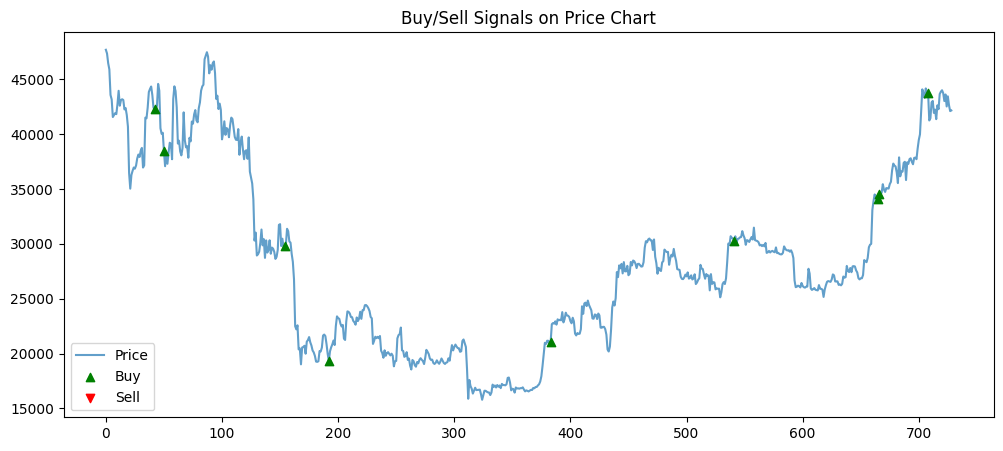

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(prices, label='Price', alpha=0.7)

buy_points = [i for i, s in enumerate(signals) if s == 1]
sell_points = [i for i, s in enumerate(signals) if s == -1]

plt.scatter(buy_points, [prices[i] for i in buy_points], 
            color='green', marker='^', label='Buy', zorder=5)
plt.scatter(sell_points, [prices[i] for i in sell_points], 
            color='red', marker='v', label='Sell', zorder=5)

plt.title('Buy/Sell Signals on Price Chart')
plt.legend()
plt.show()

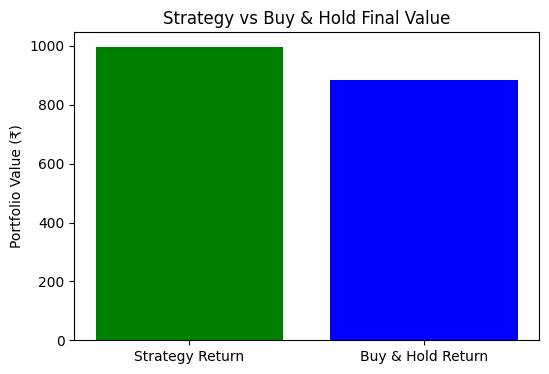

In [5]:
from sklearn.metrics import accuracy_score
import numpy as np

X_test = test[features] if 'features' in dir() else test.drop(columns=['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'return', 'future_return', 'y'])

model_accuracy = results['final_value'] / 1000
buy_hold_return = results['buy_hold'] / 1000

categories = ['Strategy Return', 'Buy & Hold Return']
values = [results['final_value'], results['buy_hold']]

plt.figure(figsize=(6, 4))
plt.bar(categories, values, color=['green', 'blue'])
plt.title('Strategy vs Buy & Hold Final Value')
plt.ylabel('Portfolio Value (₹)')
plt.show()

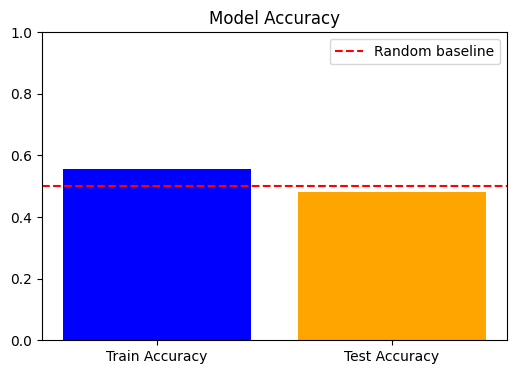

In [6]:
categories = ['Train Accuracy', 'Test Accuracy']
values = [0.5575, 0.4801]

plt.figure(figsize=(6, 4))
plt.bar(categories, values, color=['blue', 'orange'])
plt.ylim(0, 1)
plt.axhline(y=0.5, color='red', linestyle='--', label='Random baseline')
plt.title('Model Accuracy')
plt.legend()
plt.show()